<a href="https://colab.research.google.com/github/thiilelli/valeo-quality-control/blob/main/valeo_quality_control_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
from pathlib import Path

# Détection automatique de l'environnement
if 'COLAB_GPU' in os.environ:
    # Environnement Colab
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_ROOT = Path('/content/drive/MyDrive/valeo challenge')
elif os.path.exists('/kaggle/input'):
    # Environnement Kaggle
    DATA_ROOT = Path('/kaggle/input/valeo-challenge')
else:
    # Environnement local
    DATA_ROOT = Path('./data')

# Chemins dérivés (jamais à modifier)
TRAIN_IMG_DIR = DATA_ROOT / 'train_images'
TEST_IMG_DIR = DATA_ROOT / 'test_images'
TRAIN_CSV = DATA_ROOT / 'output_train.csv'
TEST_CSV = DATA_ROOT / 'output_test.csv'

print(f"✅ Data root: {DATA_ROOT}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Data root: /content/drive/MyDrive/valeo challenge


In [6]:
# ============================================================
# 🔍 EXPLORATION — Structure du dossier Valeo
# ============================================================
import os
from pathlib import Path

# Explorer les DEUX dossiers Valeo qu'on a vus
folders_to_check = ['valeo challenge', 'valeo challenge (1)']

for folder_name in folders_to_check:
    folder_path = Path('/content/drive/MyDrive') / folder_name
    print(f"\n{'='*60}")
    print(f"📂 {folder_name}")
    print(f"{'='*60}")

    if folder_path.exists():
        items = sorted(os.listdir(folder_path))
        print(f"  Nombre d'éléments : {len(items)}\n")

        for item in items[:30]:
            item_path = folder_path / item
            if item_path.is_dir():
                sub_count = len(os.listdir(item_path))
                print(f"  📁 {item}/  ({sub_count} fichiers)")
            else:
                size_mb = item_path.stat().st_size / (1024*1024)
                print(f"  📄 {item}  ({size_mb:.2f} MB)")

        if len(items) > 30:
            print(f"  ... et {len(items) - 30} autres éléments")
    else:
        print(f"  ❌ Introuvable")


📂 valeo challenge
  Nombre d'éléments : 5

  📄 Supp_files (1).zip  (560.35 MB)
  📄 Y_random_nKwalR1 (3).csv  (0.09 MB)
  📄 Y_train_eVW9jym (2).csv  (0.73 MB)
  📄 input_test_1a4aqAg (1).zip  (93.27 MB)
  📄 input_train (1).zip  (700.63 MB)

📂 valeo challenge (1)
  Nombre d'éléments : 5

  📄 Supp_files (1).zip  (560.35 MB)
  📄 Y_random_nKwalR1 (3).csv  (0.09 MB)
  📄 Y_train_eVW9jym (2).csv  (0.73 MB)
  📄 input_test_1a4aqAg (1).zip  (93.27 MB)
  📄 input_train (1).zip  (700.63 MB)


In [7]:
# ============================================================
# 📦 EXTRACTION DES ZIPs
# ============================================================
import zipfile
from pathlib import Path
import time

# Config
DRIVE_DATA = Path('/content/drive/MyDrive/valeo challenge')
LOCAL_DATA = Path('/content/valeo_data')
LOCAL_DATA.mkdir(exist_ok=True)

# Fichiers à extraire
zips_to_extract = [
    ('input_train (1).zip', 'train'),
    ('input_test_1a4aqAg (1).zip', 'test'),
]

for zip_name, subfolder in zips_to_extract:
    zip_path = DRIVE_DATA / zip_name
    extract_to = LOCAL_DATA / subfolder

    if extract_to.exists() and len(list(extract_to.iterdir())) > 0:
        print(f"✅ Déjà extrait : {subfolder} ({len(list(extract_to.iterdir()))} fichiers)")
        continue

    extract_to.mkdir(exist_ok=True)
    print(f"\n📦 Extraction de {zip_name}...")
    start = time.time()

    with zipfile.ZipFile(zip_path, 'r') as zf:
        total_files = len(zf.namelist())
        print(f"   Total : {total_files} fichiers")
        zf.extractall(extract_to)

    elapsed = time.time() - start
    print(f"   ✅ Fini en {elapsed:.1f}s")
    print(f"   → {extract_to}")

# Copier les CSVs en local aussi
import shutil
for csv_name in ['Y_train_eVW9jym (2).csv', 'Y_random_nKwalR1 (3).csv']:
    src = DRIVE_DATA / csv_name
    dst = LOCAL_DATA / csv_name
    if not dst.exists():
        shutil.copy(src, dst)
        print(f"✅ Copié : {csv_name}")

print(f"\n🎯 Tout est dans : {LOCAL_DATA}")
print(f"\n📂 Contenu :")
for item in sorted(LOCAL_DATA.iterdir()):
    if item.is_dir():
        n = len(list(item.iterdir()))
        print(f"  📁 {item.name}/  ({n} fichiers)")
    else:
        size = item.stat().st_size / (1024*1024)
        print(f"  📄 {item.name}  ({size:.2f} MB)")


📦 Extraction de input_train (1).zip...
   Total : 8279 fichiers
   ✅ Fini en 28.0s
   → /content/valeo_data/train

📦 Extraction de input_test_1a4aqAg (1).zip...
   Total : 1056 fichiers
   ✅ Fini en 7.7s
   → /content/valeo_data/test
✅ Copié : Y_train_eVW9jym (2).csv
✅ Copié : Y_random_nKwalR1 (3).csv

🎯 Tout est dans : /content/valeo_data

📂 Contenu :
  📄 Y_random_nKwalR1 (3).csv  (0.09 MB)
  📄 Y_train_eVW9jym (2).csv  (0.73 MB)
  📁 test/  (1 fichiers)
  📁 train/  (1 fichiers)


In [8]:
# ============================================================
# 🔍 EXPLORATION DES DOSSIERS EXTRAITS
# ============================================================
from pathlib import Path
import os

LOCAL_DATA = Path('/content/valeo_data')

# Explorer récursivement les 3 premiers niveaux
def explore(path, level=0, max_level=3, max_items=10):
    if level > max_level:
        return

    items = sorted(os.listdir(path))
    indent = "  " * level

    for i, item in enumerate(items[:max_items]):
        item_path = path / item
        if item_path.is_dir():
            sub_count = len(os.listdir(item_path))
            print(f"{indent}📁 {item}/  ({sub_count} items)")
            if level < max_level:
                explore(item_path, level + 1, max_level, max_items=5)
        else:
            size_kb = item_path.stat().st_size / 1024
            print(f"{indent}📄 {item}  ({size_kb:.1f} KB)")

    if len(items) > max_items:
        print(f"{indent}... et {len(items) - max_items} autres")

print("🌲 Structure de /content/valeo_data :\n")
explore(LOCAL_DATA)

🌲 Structure de /content/valeo_data :

📄 Y_random_nKwalR1 (3).csv  (88.6 KB)
📄 Y_train_eVW9jym (2).csv  (751.2 KB)
📁 test/  (1 items)
  📁 input_test/  (1055 items)
    📄 003943cefade46399db0adf9e4a1a4f14ba55033770b92b1cf16343603fe3b00.png  (62.3 KB)
    📄 004acab8e86eced72f6aa676c83f58620365b249affa2b71c9df484e0d622f1f.png  (125.2 KB)
    📄 0097035d8b03da345aab4afd2b95ff4c30c1d1f0d22cd276fa97b352b633a772.png  (64.9 KB)
    📄 00c7e00fc6db3f9b53130689de8e895107cb501aebf49922e06444fcd7b4401f.png  (104.7 KB)
    📄 0126d9e617c49a7829051ddd289cb4fef41e08f7f01ac90c05d554e446e8950e.png  (123.9 KB)
    ... et 1050 autres
📁 train/  (1 items)
  📁 input_train/  (8278 items)
    📄 00012893103b993a56e6bc460ea98a7e5cbd96b1b7277ce04094f440c01f63f0.png  (95.8 KB)
    📄 0003d3829d9f6601d6589ab3269a3506a6db1398f3da181793d51a44655586e9.png  (102.1 KB)
    📄 000a14a35b75d3e62866a225d56fa66f2a504dada691864053fc58f3afb4d762.png  (102.0 KB)
    📄 000c1ecc3a520c1948aea5b5d969ade21ffb6d0675ee0fd9dd963f8c88f8c62d

In [9]:
# ============================================================
# 📊 APERÇU DES CSVs
# ============================================================
import pandas as pd

Y_TRAIN_CSV = LOCAL_DATA / 'Y_train_eVW9jym (2).csv'
Y_RANDOM_CSV = LOCAL_DATA / 'Y_random_nKwalR1 (3).csv'

print("=" * 60)
print("📄 Y_train_eVW9jym.csv")
print("=" * 60)
df_train = pd.read_csv(Y_TRAIN_CSV)
print(f"Shape: {df_train.shape}")
print(f"Colonnes: {df_train.columns.tolist()}")
print(f"\nPremières lignes:")
print(df_train.head(10))
print(f"\nTypes:")
print(df_train.dtypes)

print("\n" + "=" * 60)
print("📄 Y_random_nKwalR1.csv (probablement template submission)")
print("=" * 60)
df_random = pd.read_csv(Y_RANDOM_CSV)
print(f"Shape: {df_random.shape}")
print(f"Colonnes: {df_random.columns.tolist()}")
print(f"\nPremières lignes:")
print(df_random.head(10))

📄 Y_train_eVW9jym.csv
Shape: (8278, 5)
Colonnes: ['Unnamed: 0', 'filename', 'window', 'lib', 'Label']

Premières lignes:
   Unnamed: 0                                           filename  window  \
0           0  15b3bab7c186fd35b65df777890c427dd243feacbb85dd...    2003   
1           1  1856617e1ac2d821a46a41b938818f0169342226a78f93...    2003   
2           2  19066cce773b3a092ebf4311b11858aa653da6f8274957...    2003   
3           3  19c10caf4b24284e1748caed62d94cbb689d6b379b1cf5...    2003   
4           4  1a627426d55a668df8bcd381a7fa87b620481995b6755f...    2003   
5           5  1a983b65277103a6e297ca45976d18e421be3d9d6fffad...    2003   
6           6  1abd8c6915e85d01ebafe6511c12f6d9a9b99a9d80b0a0...    2003   
7           7  1ac3c9fc810f266d60b6f433a0d68ef12de0948f05177d...    2003   
8           8  1ad01b91f6e470407ca10f6279f47f2756f8e9bba8137f...    2003   
9           9  1aeb4cf593126462b228dbbfab4400bdd7eb973026250b...    2003   

     lib    Label  
0  Die01  Missing  
1 

✅ Setup complete

1️⃣  DISTRIBUTION DES CLASSES (TRAIN)

Classe                       Count   Pourcent
---------------------------------------------
GOOD                          1235     14.92%
Boucle plate                    71      0.86%
Lift-off blanc                 270      3.26%
Lift-off noir                  104      1.26%
Missing                       6472     78.18%
Short circuit MOS              126      1.52%

TOTAL                         8278

2️⃣  ANALYSE DU DÉSÉQUILIBRE

  🔴 Ratio max/min : 91.2x
  🔴 Classe majeure : Missing (6472 = 78.2%)
  🔴 Classe mineure : Boucle plate (71 = 0.9%)

  💡 Class weights (inverse frequency):
     GOOD                      weight = 1.12
     Boucle plate              weight = 19.43
     Lift-off blanc            weight = 5.11
     Lift-off noir             weight = 13.27
     Missing                   weight = 0.21
     Short circuit MOS         weight = 10.95

3️⃣  MÉTADONNÉES SPATIALES

  📍 Composants (lib) uniques dans train : ['Die01'

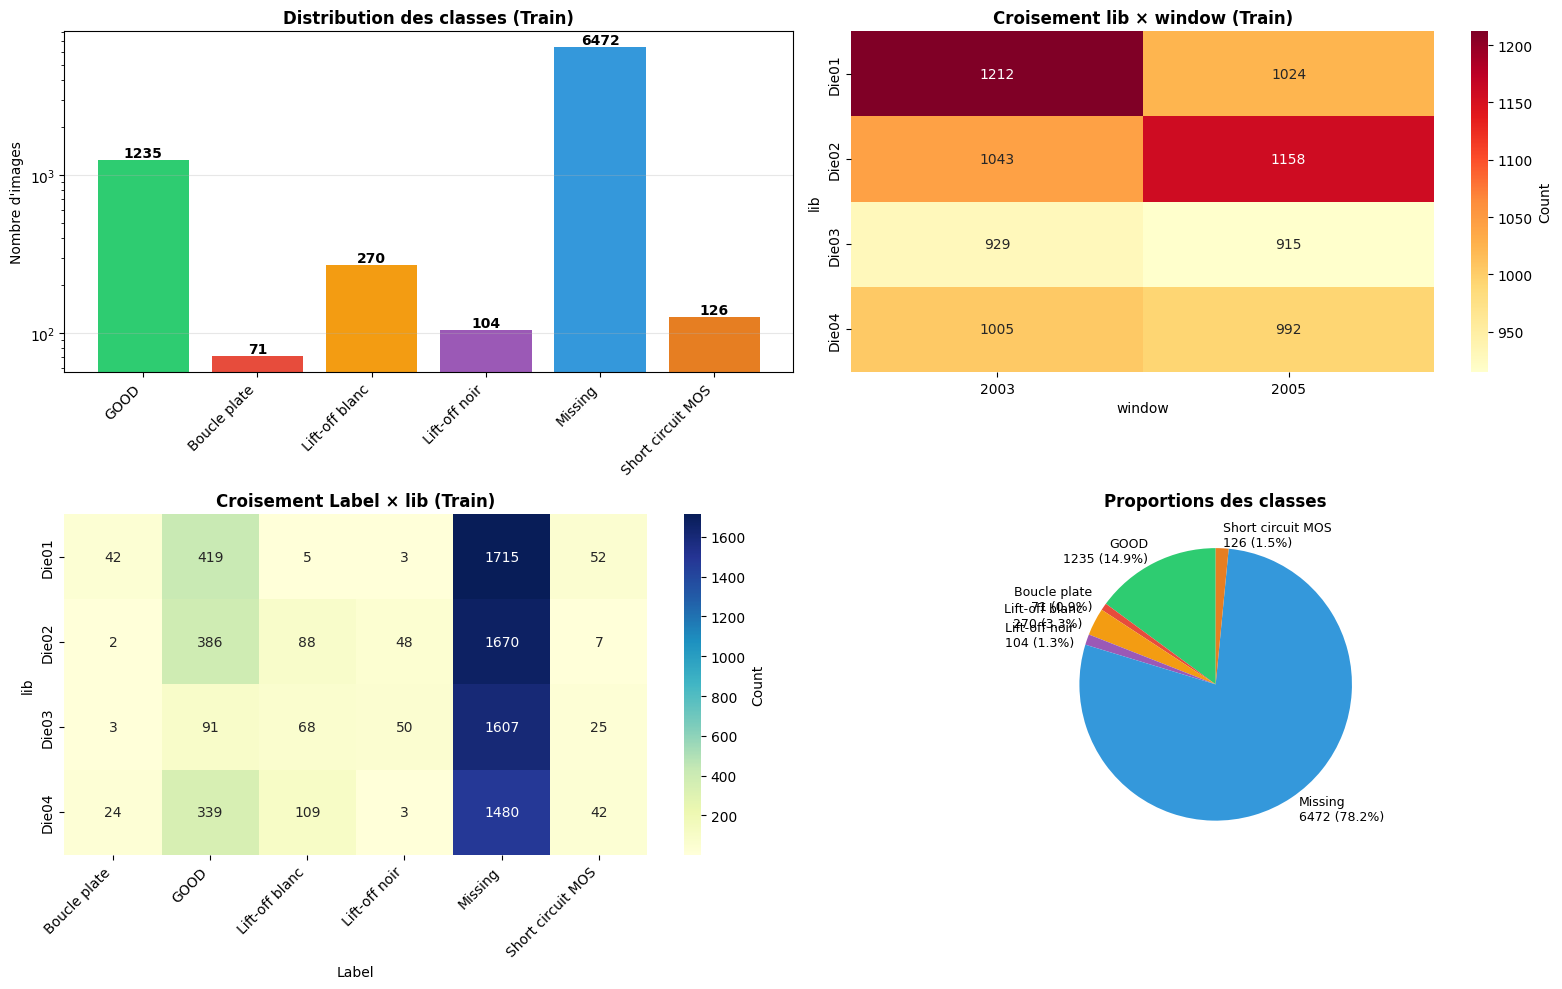

✅ Sauvé : /content/eda_overview.png


In [10]:
# ============================================================
# 📊 EDA COMPLÈTE — CHALLENGE VALEO
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Config
LOCAL_DATA = Path('/content/valeo_data')
TRAIN_IMG_DIR = LOCAL_DATA / 'train' / 'input_train'
TEST_IMG_DIR = LOCAL_DATA / 'test' / 'input_test'
Y_TRAIN_CSV = LOCAL_DATA / 'Y_train_eVW9jym (2).csv'
Y_RANDOM_CSV = LOCAL_DATA / 'Y_random_nKwalR1 (3).csv'

# Chargement
df_train = pd.read_csv(Y_TRAIN_CSV)
df_random = pd.read_csv(Y_RANDOM_CSV)

# Drop la colonne inutile
df_train = df_train.drop('Unnamed: 0', axis=1)
df_random = df_random.drop('Unnamed: 0', axis=1)

# Mapping label texte → numérique
LABEL_MAP = {
    'GOOD': 0,
    'Boucle plate': 1,
    'Lift-off blanc': 2,
    'Lift-off noir': 3,
    'Missing': 4,
    'Short circuit MOS': 5,
    'Drift': 6
}
LABEL_MAP_INV = {v: k for k, v in LABEL_MAP.items()}

# Ajouter labels numériques au train
df_train['label_num'] = df_train['Label'].map(LABEL_MAP)

print("✅ Setup complete\n")

# ============================================================
# 1️⃣ DISTRIBUTION DES CLASSES
# ============================================================
print("=" * 70)
print("1️⃣  DISTRIBUTION DES CLASSES (TRAIN)")
print("=" * 70)

class_counts = df_train['Label'].value_counts()
class_counts_ordered = pd.Series(
    [class_counts.get(name, 0) for name in LABEL_MAP.keys() if name != 'Drift'],
    index=[name for name in LABEL_MAP.keys() if name != 'Drift']
)

print("\n{:<25} {:>8} {:>10}".format('Classe', 'Count', 'Pourcent'))
print("-" * 45)
for name, count in class_counts_ordered.items():
    pct = 100 * count / len(df_train)
    print(f"{name:<25} {count:>8} {pct:>9.2f}%")
print(f"\n{'TOTAL':<25} {len(df_train):>8}")

# ============================================================
# 2️⃣ DÉSÉQUILIBRE
# ============================================================
print("\n" + "=" * 70)
print("2️⃣  ANALYSE DU DÉSÉQUILIBRE")
print("=" * 70)
ratio = class_counts_ordered.max() / class_counts_ordered.min()
print(f"\n  🔴 Ratio max/min : {ratio:.1f}x")
print(f"  🔴 Classe majeure : {class_counts_ordered.idxmax()} ({class_counts_ordered.max()} = {100*class_counts_ordered.max()/len(df_train):.1f}%)")
print(f"  🔴 Classe mineure : {class_counts_ordered.idxmin()} ({class_counts_ordered.min()} = {100*class_counts_ordered.min()/len(df_train):.1f}%)")

# Class weights recommandés
print(f"\n  💡 Class weights (inverse frequency):")
total = len(df_train)
n_classes = len(class_counts_ordered)
for name, count in class_counts_ordered.items():
    weight = total / (n_classes * count)
    print(f"     {name:<25} weight = {weight:.2f}")

# ============================================================
# 3️⃣ MÉTADONNÉES SPATIALES (lib × window)
# ============================================================
print("\n" + "=" * 70)
print("3️⃣  MÉTADONNÉES SPATIALES")
print("=" * 70)

print(f"\n  📍 Composants (lib) uniques dans train : {sorted(df_train['lib'].unique())}")
print(f"  📍 Windows uniques dans train : {sorted(df_train['window'].unique())}")
print(f"\n  📍 Composants (lib) uniques dans test : {sorted(df_random['lib'].unique())}")
print(f"  📍 Windows uniques dans test : {sorted(df_random['window'].unique())}")

# Check overlap train/test
train_libs = set(df_train['lib'].unique())
test_libs = set(df_random['lib'].unique())
train_windows = set(df_train['window'].unique())
test_windows = set(df_random['window'].unique())

print(f"\n  ⚠️  Domaines train ∩ test :")
print(f"     lib: train seul = {train_libs - test_libs}, test seul = {test_libs - train_libs}")
print(f"     window: train seul = {train_windows - test_windows}, test seul = {test_windows - train_windows}")

# Croisement
print(f"\n  📊 lib × window en TRAIN :")
cross_tab_train = pd.crosstab(df_train['lib'], df_train['window'], margins=True)
print(cross_tab_train)

print(f"\n  📊 lib × label en TRAIN :")
cross_lib_label = pd.crosstab(df_train['lib'], df_train['Label'])
print(cross_lib_label)

# ============================================================
# 4️⃣ VISUALISATIONS
# ============================================================
print("\n" + "=" * 70)
print("4️⃣  GÉNÉRATION DES VISUALISATIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Distribution classes
ax = axes[0, 0]
colors = ['#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#3498db', '#e67e22']
bars = ax.bar(range(len(class_counts_ordered)), class_counts_ordered.values, color=colors)
ax.set_xticks(range(len(class_counts_ordered)))
ax.set_xticklabels(class_counts_ordered.index, rotation=45, ha='right')
ax.set_ylabel('Nombre d\'images')
ax.set_title('Distribution des classes (Train)', fontweight='bold', fontsize=12)
ax.set_yscale('log')
for i, (bar, val) in enumerate(zip(bars, class_counts_ordered.values)):
    ax.text(bar.get_x() + bar.get_width()/2, val, str(val),
            ha='center', va='bottom', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Répartition lib × window (heatmap)
ax = axes[0, 1]
cross_no_margins = pd.crosstab(df_train['lib'], df_train['window'])
sns.heatmap(cross_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Croisement lib × window (Train)', fontweight='bold', fontsize=12)

# Plot 3: Répartition label × lib
ax = axes[1, 0]
sns.heatmap(cross_lib_label, annot=True, fmt='d', cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Count'})
ax.set_title('Croisement Label × lib (Train)', fontweight='bold', fontsize=12)
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Plot 4: Pie chart proportions
ax = axes[1, 1]
sizes = class_counts_ordered.values
labels = [f'{name}\n{val} ({100*val/sum(sizes):.1f}%)' for name, val in class_counts_ordered.items()]
ax.pie(sizes, labels=labels, colors=colors, startangle=90, textprops={'fontsize': 9})
ax.set_title('Proportions des classes', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('/content/eda_overview.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Sauvé : /content/eda_overview.png")

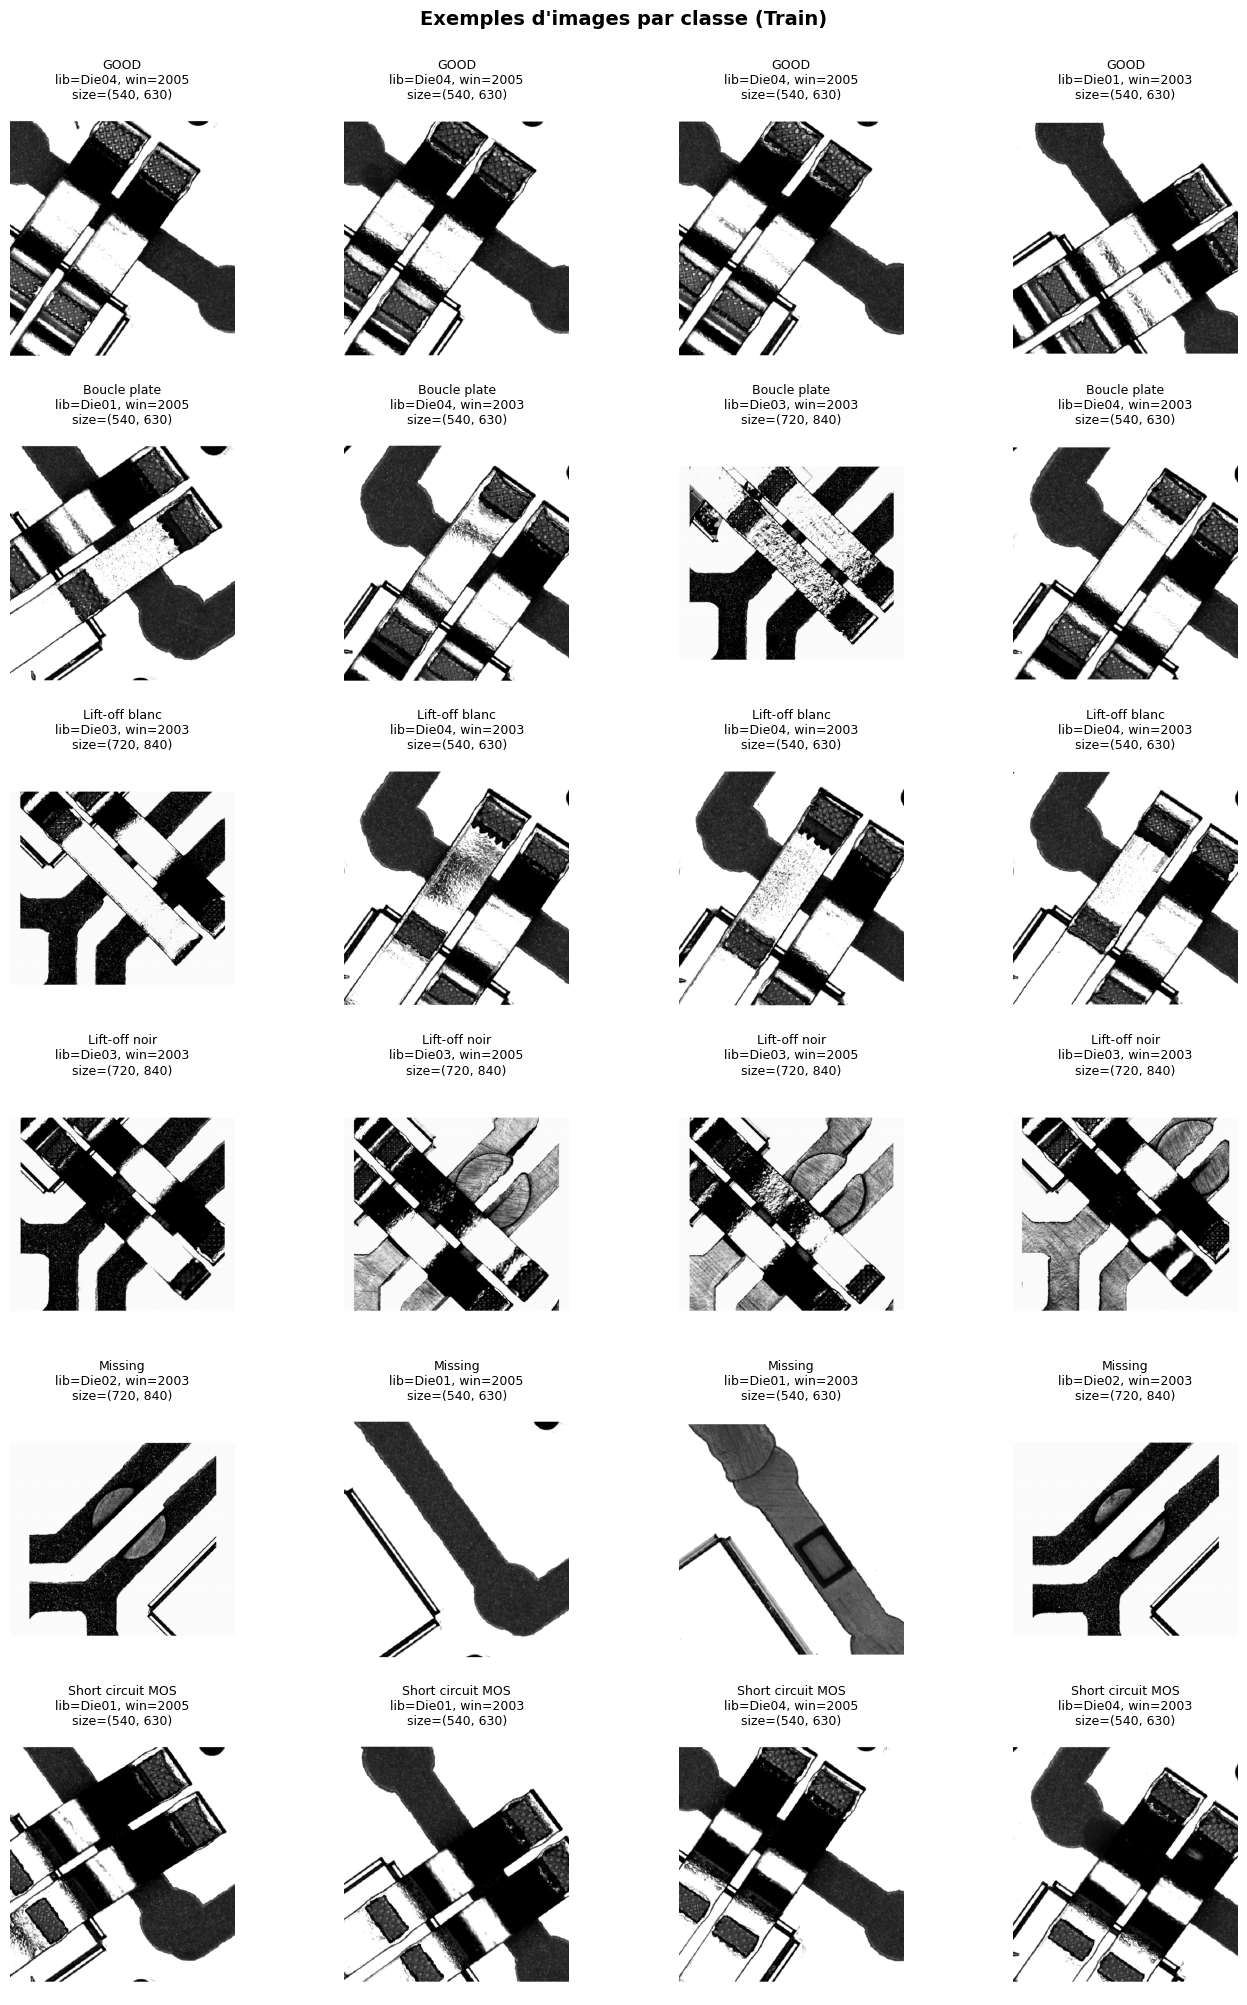

✅ Sauvé : /content/samples_per_class.png

6️⃣  STATISTIQUES DES IMAGES


Scan images: 100%|██████████| 500/500 [00:00<00:00, 527.41it/s]



✅ 500 images scannées

📐 Résolutions :
   Largeur  : min=540, max=1170, moyenne=625, médiane=540
   Hauteur  : min=630, max=1365, moyenne=729, médiane=630

🎨 Modes de couleur : {'L'}
📄 Formats : {'PNG'}


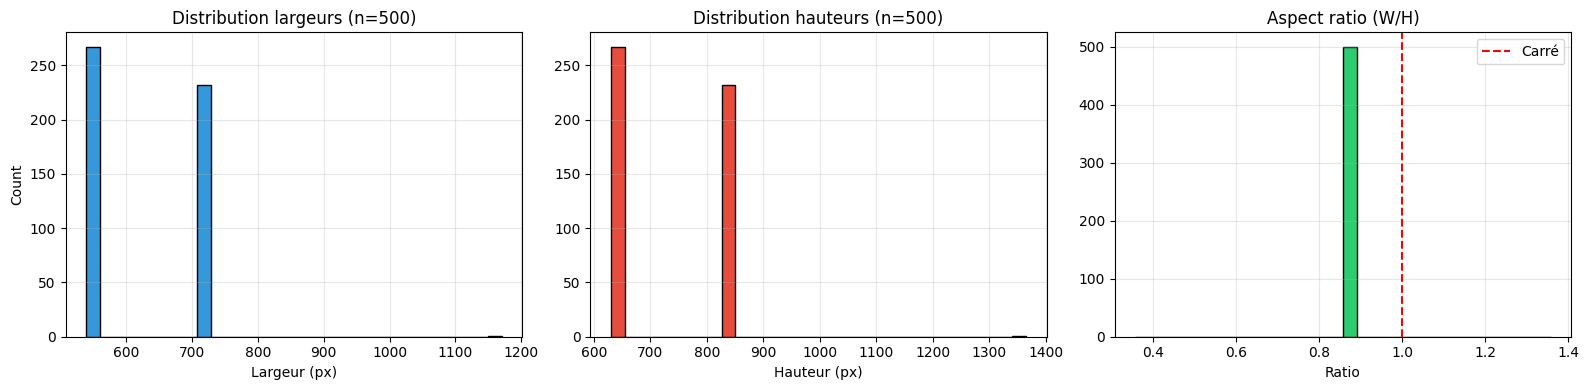

✅ Sauvé : /content/image_stats.png

📐 Top 10 résolutions rencontrées :
   540×630 : 267 images (53.4%)
   720×840 : 232 images (46.4%)
   1170×1365 : 1 images (0.2%)


In [15]:
# ============================================================
# 5️⃣ + 6️⃣ EXPLORATION VISUELLE + STATS IMAGES (CORRIGÉ)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

# --- SAMPLES PAR CLASSE ---
classes_to_show = ['GOOD', 'Boucle plate', 'Lift-off blanc',
                   'Lift-off noir', 'Missing', 'Short circuit MOS']

fig, axes = plt.subplots(6, 4, figsize=(14, 20))
fig.suptitle('Exemples d\'images par classe (Train)', fontsize=14, fontweight='bold', y=1.00)

for row_idx, class_name in enumerate(classes_to_show):
    subset = df_train[df_train['Label'] == class_name]
    samples = subset.sample(min(4, len(subset)), random_state=42)

    for col_idx, (_, row) in enumerate(samples.iterrows()):
        ax = axes[row_idx, col_idx]

        # ✅ CORRIGÉ : filename contient déjà .png
        img_path = TRAIN_IMG_DIR / row['filename']

        if img_path.exists():
            img = Image.open(img_path)
            ax.imshow(img, cmap='gray')
            ax.set_title(f"{class_name}\nlib={row['lib']}, win={row['window']}\nsize={img.size}",
                        fontsize=9)
        else:
            ax.text(0.5, 0.5, f'Not found:\n{row["filename"][:20]}...',
                    ha='center', va='center', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig('/content/samples_per_class.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Sauvé : /content/samples_per_class.png\n")

# --- STATS IMAGES ---
print("=" * 70)
print("6️⃣  STATISTIQUES DES IMAGES")
print("=" * 70)

n_scan = 500
sample_df = df_train.sample(n_scan, random_state=42)

widths, heights, modes, formats = [], [], [], []
for _, row in tqdm(sample_df.iterrows(), total=n_scan, desc="Scan images"):
    # ✅ CORRIGÉ ici aussi
    img_path = TRAIN_IMG_DIR / row['filename']
    if img_path.exists():
        img = Image.open(img_path)
        widths.append(img.width)
        heights.append(img.height)
        modes.append(img.mode)
        formats.append(img.format)

print(f"\n✅ {len(widths)} images scannées")

print(f"\n📐 Résolutions :")
print(f"   Largeur  : min={min(widths)}, max={max(widths)}, moyenne={np.mean(widths):.0f}, médiane={np.median(widths):.0f}")
print(f"   Hauteur  : min={min(heights)}, max={max(heights)}, moyenne={np.mean(heights):.0f}, médiane={np.median(heights):.0f}")
print(f"\n🎨 Modes de couleur : {set(modes)}")
print(f"📄 Formats : {set(formats)}")

# Histogrammes
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(widths, bins=30, color='#3498db', edgecolor='black')
axes[0].set_title(f'Distribution largeurs (n={len(widths)})')
axes[0].set_xlabel('Largeur (px)')
axes[0].set_ylabel('Count')
axes[0].grid(alpha=0.3)

axes[1].hist(heights, bins=30, color='#e74c3c', edgecolor='black')
axes[1].set_title(f'Distribution hauteurs (n={len(heights)})')
axes[1].set_xlabel('Hauteur (px)')
axes[1].grid(alpha=0.3)

aspect_ratios = np.array(widths) / np.array(heights)
axes[2].hist(aspect_ratios, bins=30, color='#2ecc71', edgecolor='black')
axes[2].set_title(f'Aspect ratio (W/H)')
axes[2].set_xlabel('Ratio')
axes[2].axvline(1, color='red', linestyle='--', label='Carré')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/image_stats.png', dpi=100, bbox_inches='tight')
plt.show()
print("✅ Sauvé : /content/image_stats.png")

# Top résolutions
import pandas as pd
res_pairs = [(w, h) for w, h in zip(widths, heights)]
res_counts = pd.Series(res_pairs).value_counts().head(10)
print(f"\n📐 Top 10 résolutions rencontrées :")
for (w, h), count in res_counts.items():
    print(f"   {w}×{h} : {count} images ({100*count/len(widths):.1f}%)")